# **6주차 강화학습 실습**

안녕하세요.

Tobig's 24기 서민정, 정서윤입니다.

본 실습은 3x4 그리드 월드(GridWorld) 환경에서 에이전트가 함정을 피하고 목표 지점에 도달하는 최적의 경로를 학습하는 과정을 다룹니다.

환경의 완벽한 정보를 안다고 가정하는 동적 계획법(DP)부터, 경험을 통해 학습하는 몬테카를로(MC)와 시간차 학습(TD) 알고리즘까지 순차적으로 구현해봅니다. 이를 통해 각 강화학습 알고리즘의 작동 원리를 깊이 이해하고, 실질적인 차이점을 비교 분석해보겠습니다.

# **3x4 그리드 월드**

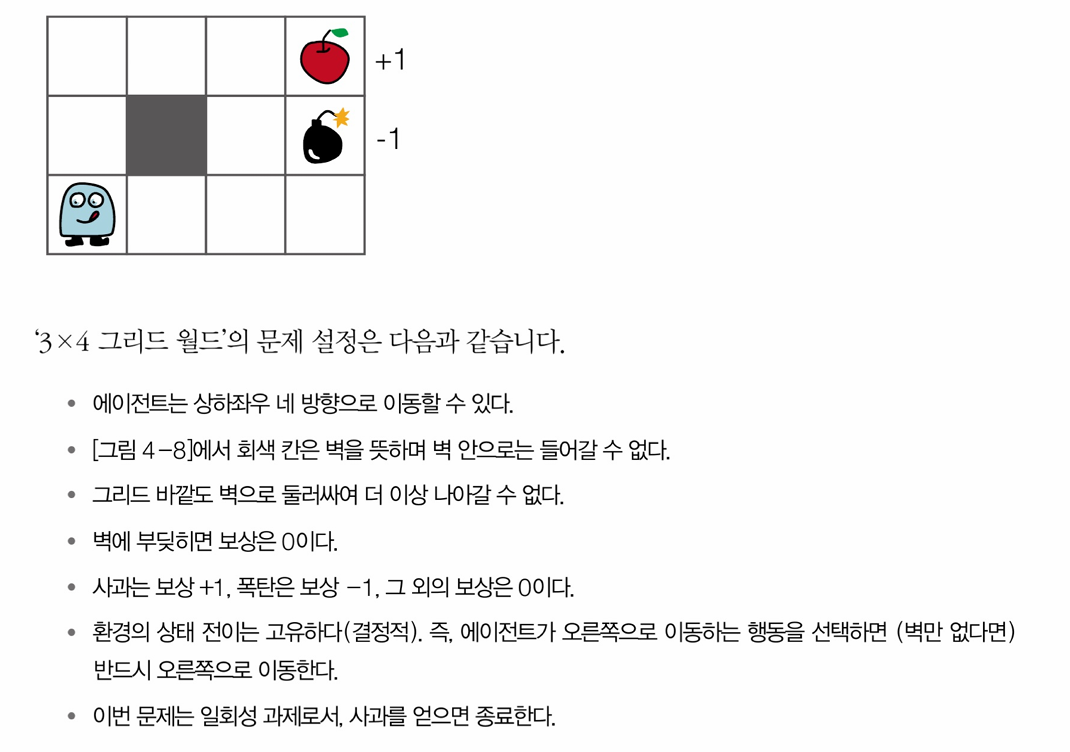

# **동적 프로그래밍(Dynamic Programming)**

동적 계획법은 환경의 전이 확률과 보상 함수를 모두 알고 있다는 가정 하에 동작합니다. 가치 반복(Value Iteration)은 벨만 최적 방정식을 업데이트 규칙으로 사용하여, 상태 가치 함수가 수렴할 때까지 반복 계산하여 최적 가치 함수와 최적 정책을 찾습니다.

**SETUP**

In [ ]:
# install required packages locally
import importlib.util
import os
import subprocess
import sys

target_dir = os.path.join(os.getcwd(), ".pydeps_rl")
os.makedirs(target_dir, exist_ok=True)

if target_dir not in sys.path:
    sys.path.insert(0, target_dir)

missing = [pkg for pkg in ["dezerogym", "matplotlib"] if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--target", target_dir, *missing])

**1. 환경 초기화 및 무작위 가치 함수 시각화**

/Users/zzuhyeong2/Documents/Tobig's 25th/.pydeps_rl/dezerogym/gridworld_render.py:88: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


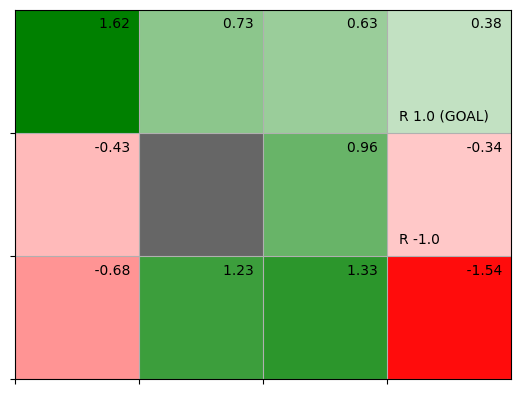

In [ ]:
import numpy as np
from dezerogym.gridworld import GridWorld

env = GridWorld()
V = {}

for state in env.states():
    V[state] = np.random.randn()
env.render_v(V)

**2. 정책 평가 (Policy Evaluation)**

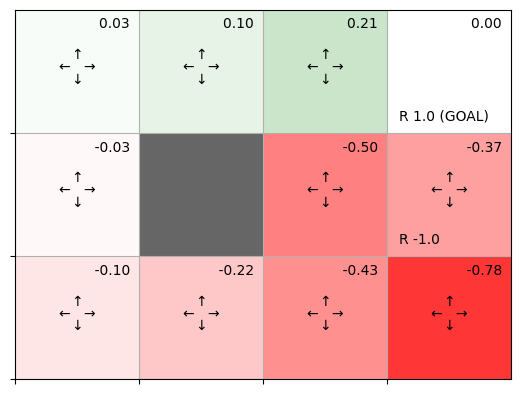

In [ ]:
from collections import defaultdict
from dezerogym.gridworld import GridWorld


def eval_onestep(pi, V, env, gamma=0.9):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_probs = pi[state]
        new_V = 0
        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            new_V += action_prob * (r + gamma * V[next_state])
        V[state] = new_V
    return V


def policy_eval(pi, V, env, gamma, threshold=0.001):
    while True:
        old_V = V.copy()
        V = eval_onestep(pi, V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
V = defaultdict(lambda: 0)

V = policy_eval(pi, V, env, gamma)
env.render_v(V, pi)

**3. 정책 반복 (Policy Iteration)**

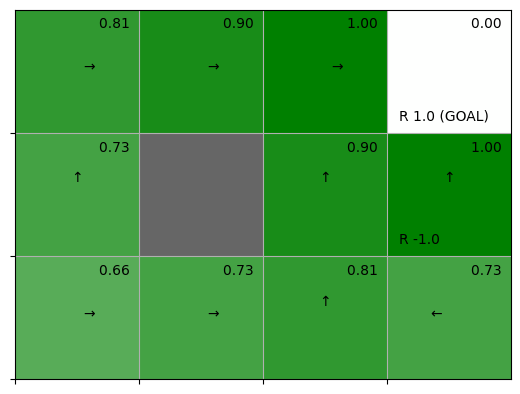

In [ ]:
def argmax(d):
    """d (dict)"""
    max_value = max(d.values())
    max_key = -1
    for key, value in d.items():
        if value == max_value:
            max_key = key
    return max_key


def greedy_policy(V, env, gamma):
    pi = {}

    for state in env.states():
        action_values = {}

        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value

        max_action = argmax(action_values)
        action_probs = {0: 0, 1: 0, 2: 0, 3: 0}
        action_probs[max_action] = 1.0
        pi[state] = action_probs
    return pi


def policy_iter(env, gamma, threshold=0.001, is_render=True):
    pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)
        new_pi = greedy_policy(V, env, gamma)

        if is_render:
            env.render_v(V, pi)

        if new_pi == pi:
            break
        pi = new_pi

    return pi


env = GridWorld()
gamma = 0.9
pi = policy_iter(env, gamma, is_render=False)
V = policy_eval(pi, defaultdict(lambda: 0), env, gamma)
env.render_v(V, pi)

**4. 가치 반복 (Value Iteration)**

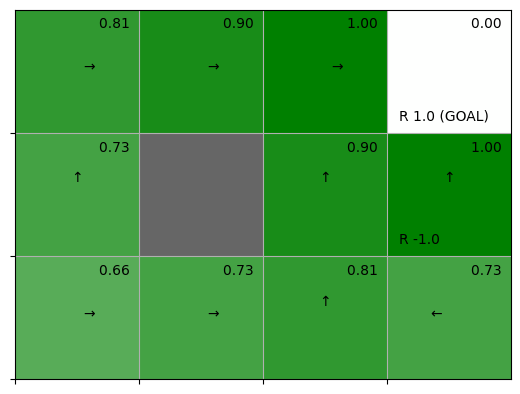

In [ ]:
def value_iter_onestep(V, env, gamma):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_values = []
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values.append(value)

        V[state] = max(action_values)
    return V


def value_iter(V, env, gamma, threshold=0.001, is_render=True):
    while True:
        if is_render:
            env.render_v(V)

        old_V = V.copy()
        V = value_iter_onestep(V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


V = defaultdict(lambda: 0)
env = GridWorld()
gamma = 0.9

V = value_iter(V, env, gamma, is_render=False)

pi = greedy_policy(V, env, gamma)
env.render_v(V, pi)

# **몬테카를로법(Monte Carlo Method)**

몬테카를로 방법은 환경의 모델을 모를 때, 에이전트가 직접 환경과 상호작용하며 얻은 에피소드(경험)를 바탕으로 학습합니다. 에피소드가 끝날 때까지 기다렸다가 실제 얻은 반환값을 사용하여 Q-함수를 업데이트합니다. 여기서 구현하는 비활성 정책(Off-policy) MC는 탐험을 위한 행동 정책(Behavior Policy)과 최적화하려는 목표 정책(Target Policy)을 분리하고 중요도 샘플링을 적용합니다.

**SETUP**

In [ ]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld

**1. 무작위 에이전트를 이용한 MC 정책 평가**

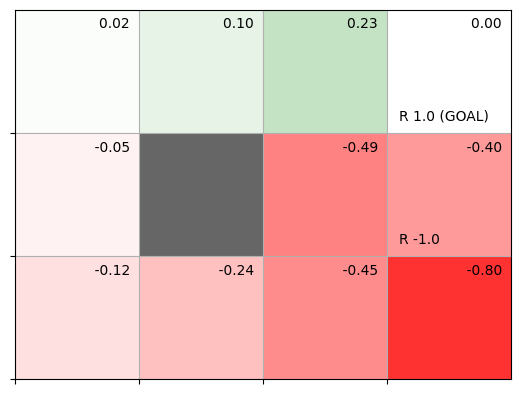

In [ ]:
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def eval(self):
        G = 0
        for data in reversed(self.memory):  # 역방향으로(reserved) 따라가기
            state, action, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1
            self.V[state] += (G - self.V[state]) / self.cnts[state]


env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):  # 에피소드 1000번 수행
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)             # 행동 선택
        next_state, reward, done = env.step(action)  # 행동 수행

        agent.add(state, action, reward)  # (상태, 행동, 보상) 저장
        if done:   # 목표에 도달 시
            agent.eval()  # 몬테카를로법으로 가치 함수 갱신
            break         # 다음 에피소드 시작

        state = next_state

# 모든 에피소드 종료

# 가치 함수 시각화
env.render_v(agent.V)

**[공통 유틸리티] 엡실론-탐욕(epsilon-greedy) 확률 계산 함수**

In [ ]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**2. 활성 정책 MC 제어 (On-Policy MC Control)**

/Users/zzuhyeong2/Documents/Tobig's 25th/.pydeps_rl/dezerogym/gridworld_render.py:150: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


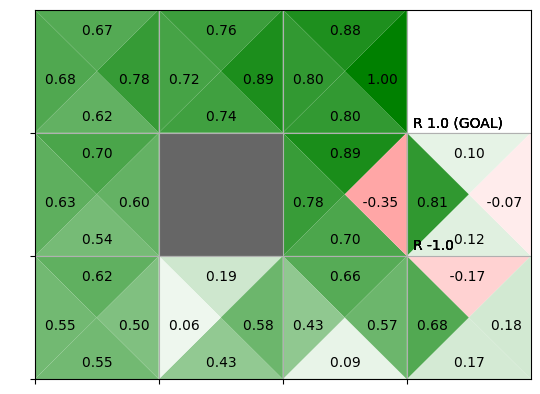

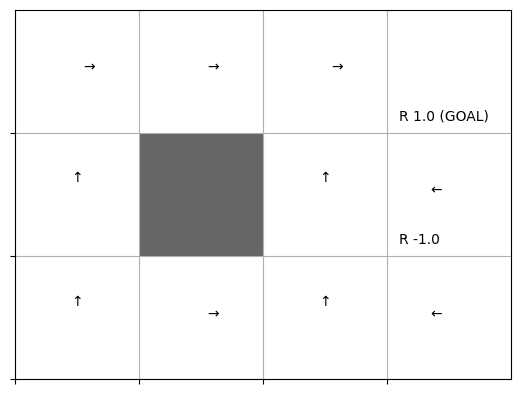

In [ ]:
class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1  # (첫 번째 개선) ε-탐욕 정책의 ε
        self.alpha = 0.1    # (두 번째 개선) Q 함수 갱신 시의 고정값 α
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        # self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            # self.cnts[key] += 1
            # self.Q[key] += (G - self.Q[key]) / self.cnts[key]
            self.Q[key] += (G - self.Q[key]) * self.alpha
            self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 MC 제어 (Off-Policy MC Control)**

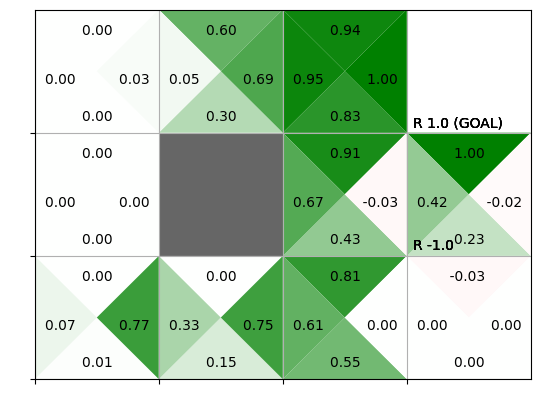

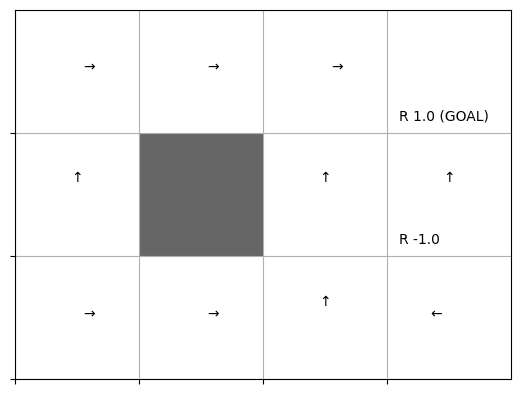

In [ ]:
class McOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.2
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        rho = 1

        for data in reversed(self.memory):
            state, action, reward = data
            key = (state, action)

            G = self.gamma * rho * G + reward
            self.Q[key] += (G - self.Q[key]) * self.alpha
            rho *= self.pi[state][action] / self.b[state][action]

            self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
            self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

# **TD법(Temporal Difference Methods)**

시간차(TD) 학습은 MC와 마찬가지로 모델 없이 학습하지만, 에피소드가 끝날 때까지 기다리지 않고 매 타임스텝마다 학습합니다. Q-Learning은 TD의 대표적인 비활성 정책 제어 알고리즘으로, 다음 상태에서 가능한 가장 큰 Q-값을 다음 타겟으로 사용하여 현재 상태의 Q-값을 실시간으로 업데이트합니다.

**[공통 유틸리티 함수]**

In [ ]:
# utility functions (common functions)
def argmax(xs):
    idxes = [i for i, x in enumerate(xs) if x == max(xs)]
    if len(idxes) == 1:
        return idxes[0]
    elif len(idxes) == 0:
        return np.random.choice(len(xs))
    selected = np.random.choice(idxes)
    return selected

def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = argmax(qs)  # OR np.argmax(qs)
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**1. TD 정책 평가 (TD Evaluation)**

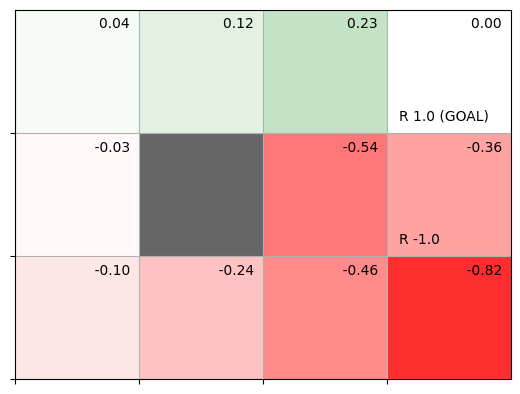

In [ ]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld


class TdAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.01
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state]
        target = reward + self.gamma * next_V
        self.V[state] += (target - self.V[state]) * self.alpha


env = GridWorld()
agent = TdAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_v(agent.V)

**2. SARSA (활성 정책 TD 제어, On-Policy TD Control)**

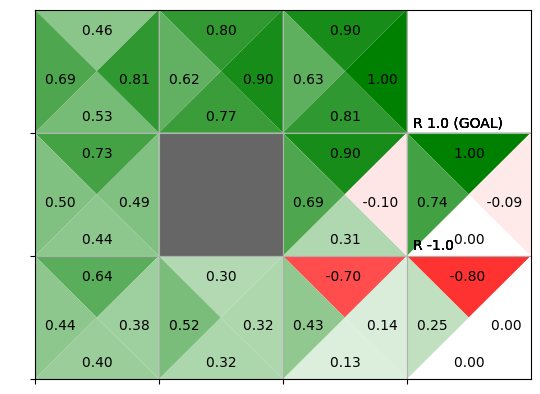

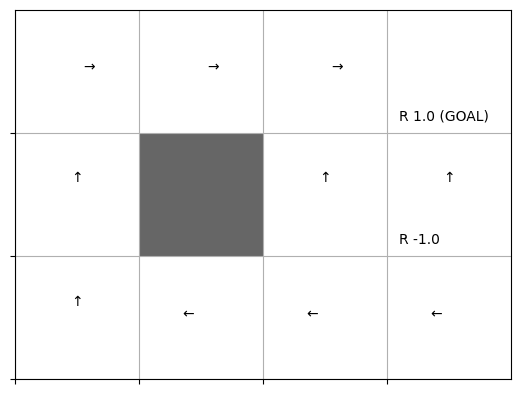

In [ ]:
from collections import deque


class SarsaAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]
        next_q = 0 if done else self.Q[next_state, next_action]

        target = reward + self.gamma * next_q
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha
        self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 SARSA (Off-Policy SARSA)**

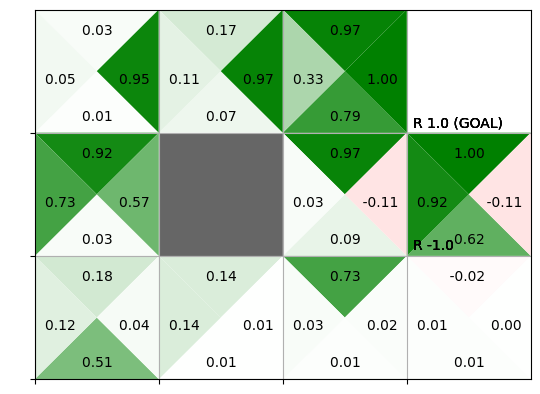

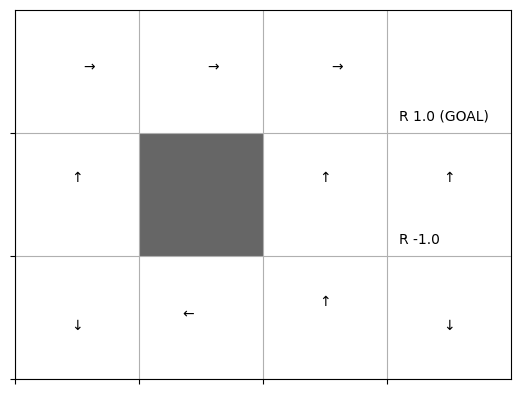

In [ ]:
class SarsaOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]

        target = rho * (reward + self.gamma * next_q)
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, 0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**4. Q-Learning (버전 1: 목표 정책 pi와 행동 정책 b 명시적 분리)**

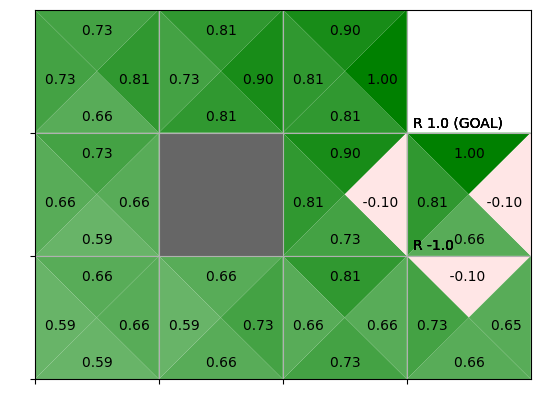

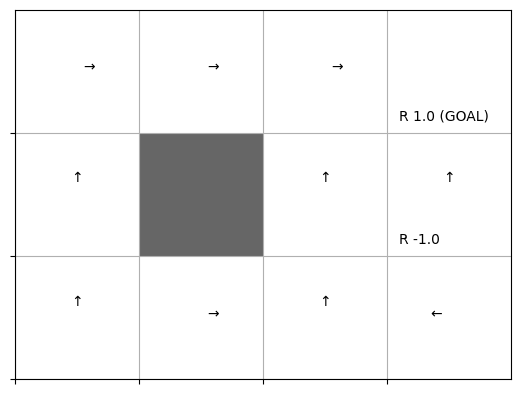

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

**5. Q-Learning (버전 2: 딕셔너리로 b와 pi를 유지하지 않고, get_action에서 즉석으로 엡실론-탐욕을 계산하여 메모리와 연산을 최적화)**

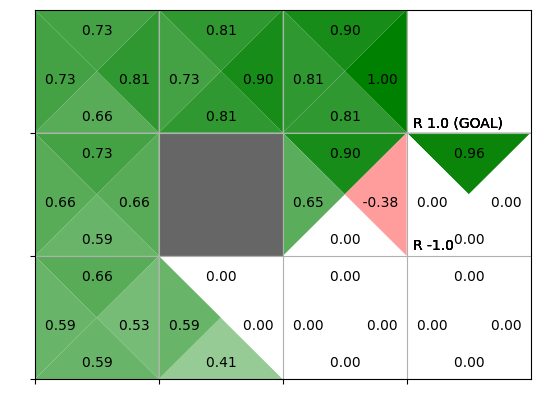

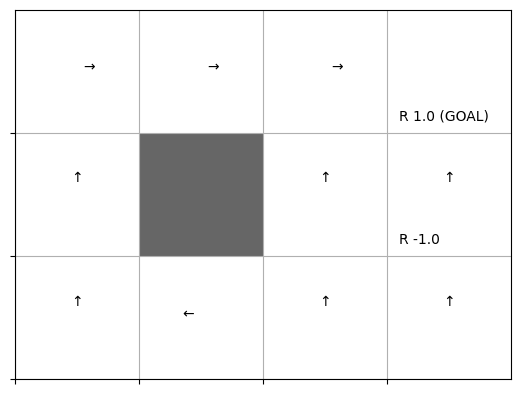

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = [self.Q[state, a] for a in range(self.action_size)]
            return np.argmax(qs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha


env = GridWorld()
agent = QLearningAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

# **결과 분석 및 서술형 문제**

■ 과제 수행 방법:

DP, MC, TD의 모든 에이전트 코드를 순서대로 실행해보십시오. 각 학습이 완료된 후 출력되는 그리드월드 상의 가치(Value) 또는 Q-값(상태-행동 가치)과 에이전트의 정책 방향 화살표를 주의 깊게 관찰한 뒤, 아래의 질문에 대해 서술형으로 답안을 작성하여 제출 바랍니다.

**[문제 1]**

동적 계획법(DP)의 value_iter 코드와 시간차 학습(TD)의 QLearningAgent 코드를 비교해 보십시오.

DP는 에피소드를 진행하며 환경과 상호작용할 필요 없이 가치를 계산할 수 있었습니다. 그 이유(DP의 전제 조건)가 무엇인지 설명하고, 자율주행이나 주식 거래와 같은 현실 세계의 복잡한 문제에서 DP 대신 MC나 TD와 같은 모델 프리(Model-free) 알고리즘을 사용해야만 하는 이유를 서술하시오.

답안:

DP가 에피소드를 실제로 굴리지 않고도 가치를 계산할 수 있었던 이유는 환경의 모델을 완전히 안다고 가정하기 때문이다. 여기서 말하는 모델은 상태 전이와 보상 함수다. 즉 어떤 상태에서 어떤 행동을 했을 때 다음 상태가 어디로 가는지, 그리고 그때 보상이 얼마인지가 이미 정해져 있으므로, 코드는 `env.next_state(...)`와 `env.reward(...)`를 직접 호출하면서 모든 경우를 테이블처럼 계산할 수 있다. 그래서 DP는 샘플을 모으지 않아도 벨만 방정식을 반복 적용해 가치 함수와 최적 정책을 구할 수 있다.

하지만 자율주행이나 주식 거래 같은 현실 문제는 이런 전제가 잘 성립하지 않는다. 자율주행은 주변 차량, 보행자, 날씨, 센서 오차처럼 변수가 너무 많아서 정확한 전이 확률을 모델로 써두기 어렵다. 주식 시장도 다른 참여자의 행동과 외부 뉴스에 따라 계속 바뀌기 때문에, 이 행동을 하면 다음 상태가 반드시 이렇게 된다 식의 정의가 사실상 불가능하다. 결국 현실에서는 환경의 동역학을 완벽히 아는 대신, 직접 상호작용하며 데이터를 모아야 한다.

이 지점에서 MC나 TD 같은 모델 프리 알고리즘이 필요해진다. 이들은 전이 함수를 몰라도 실제 경험 `(state, action, reward, next_state)`만으로 가치를 추정할 수 있다. MC는 에피소드가 끝난 뒤 실제 반환값으로 학습하고, TD는 한 스텝 뒤의 추정값까지 활용해 더 빠르게 갱신한다. 정리하면 DP는 사전 지식이 있는 학습이고, MC와 TD는 경험 위주의 학습이라서 현실 문제에는 Model-free 방식이 훨씬 실용적이다.

**[문제 2]**

몬테카를로 제어(McAgent)와 시간차 제어(SarsaAgent) 코드를 보면 에이전트의 가치(self.Q)를 업데이트하는 시점(메서드 호출 시점)이 다릅니다.

1. 두 알고리즘이 각각 어느 시점에 가치를 업데이트하는지 코드를 바탕으로 설명하시오.

2. 이러한 업데이트 시점의 차이로 인해 발생하는 장단점(학습 속도, 편향과 분산 등)을 비교하여 서술하시오.

답안:

1. 코드 기준으로 보면 MC 제어(`McAgent`)는 에피소드가 완전히 끝난 뒤에 한꺼번에 업데이트한다. 학습 루프에서 `done`이 `True`가 되면 그제서야 `agent.update()`가 호출되고, 이 method는 `reversed(self.memory)`로 에피소드 전체를 뒤에서부터 따라가며 반환값 `G`를 계산한 후 Q값을 고친다. 즉 중간에는 아무것도 배우지 않고, 에피소드를 마친 후에 학습한다.

반면 SARSA(`SarsaAgent`)는 매 스텝마다 바로 업데이트를 시도한다. 루프 안에서 행동을 한 직후 `agent.update(state, action, reward, done)`이 호출되고, `deque(maxlen=2)`에 최근 두 전이를 저장한 다음, 길이가 2가 되면 이전 시점의 `(state, action)`을 즉시 갱신한다. 마지막 종료 시점에는 한 번 더 `agent.update(next_state, None, None, None)`를 호출해서 끝 직전 상태도 처리한다. 즉 SARSA는 에피소드 종료를 기다리지 않고 매 스텝에 학습하는 구조다.

2. 1.의 차이 때문에 장단점이 발생한다. MC는 실제로 끝까지 가서 얻은 반환값으로 업데이트하므로 결과의 신뢰성이 상승한다. 중간 추정치를 섞지 않아서 부트스트래핑에 따른 편향은 적은 편이다. 대신 에피소드가 끝나야 학습할 수 있기 때문에 업데이트가 느리고, 반환값이 에피소드 전체에 크게 흔들려 분산이 크다. 특히 에피소드가 길거나 보상이 드문 환경에서는 학습 신호가 늦게 와서 비효율적이다.

SARSA는 한 스텝마다 바로 갱신하므로 훨씬 빠르게 반응한다. 새 경험이 들어오자마자 정책이 조금씩 수정되기 때문에 온라인 학습에 유리하고, 긴 에피소드에서도 지속적으로 개선이 가능하다. 다만 다음 상태의 추정 Q값을 이용하는 부트스트래핑 방식이라서 편향이 들어갈 수 있다. 대신 분산은 MC보다 작아지는 경우가 많아 실제 학습은 더 안정적으로 보이기도 한다.

요약하면 MC는 느리지만 직접적인 반환값을 쓰는 방식, SARSA는 빠르지만 추정값을 섞어 배우는 방식이라고 볼 수 있다.

**[문제 3]**

TD 학습 파트에서 SarsaAgent(활성 정책)와 QLearningAgent(비활성 정책)의 update 메서드 내부를 살펴보면, TD 타겟(Target)을 계산하는 방식에 핵심적인 차이가 있습니다.

1. SARSA는 타겟 계산을 위해 다음 상태의 어떤 값을 참조하며, Q-Learning은 어떤 값을 참조하는지 코드의 구체적인 변수명이나 로직을 들어 설명하시오.

2. 이 차이로 인해 그리드월드의 '함정' 근처에서 두 에이전트가 학습하는 최적 경로(안전 추구 vs. 최단 경로 추구)가 어떻게 달라질 수 있는지 추론하여 서술하시오.

답안:

1. SARSA는 다음 상태에서 실제로 선택한 행동의 Q값을 참조한다. 코드에서 보면 `next_state, next_action, _, _ = self.memory[1]`로 다음 상태와 다음 행동을 꺼낸 뒤, `next_q = 0 if done else self.Q[next_state, next_action]`로 타깃을 만든다. 즉 타깃은 `reward + gamma * Q(next_state, next_action)` 꼴이다. 여기서 중요한 점은 `next_action`이 현재 정책에 따라 실제로 선택된 행동이라는 점이다.

Q-Learning은 다르게, 다음 상태에서 가능한 행동들 중 가장 큰 Q값을 참조한다. 코드에서는 `next_qs = [self.Q[next_state, a] for a in range(self.action_size)]`를 만든 다음 `next_q_max = max(next_qs)`를 사용한다. 즉 타깃은 `reward + gamma * max_a Q(next_state, a)` 꼴이다. 실제로 다음에 무엇을 했는지는 중요하지 않고, 그 상태에서 이론상 가장 좋은 행동의 가치만 가져온다.

2. 위의 차이 때문에 함정 근처에서 두 알고리즘의 성향이 갈릴 수 있다. SARSA는 현재 탐험 정책의 영향을 그대로 반영한다. 다시 말해 다음 상태에서 ε-greedy로 행동하다가 실수로 함정 쪽으로 갈 가능성까지 고려해서 학습한다. 그래서 함정 근처처럼 실수했을 때 손해가 큰 구간에서는 조금 돌아가더라도 더 안전한 경로를 선호하는 쪽으로 학습되기 쉽다.

반면 Q-Learning은 다음 상태에서 항상 최댓값만 본다. 실제 탐험 중에는 잘못된 행동을 할 수 있어도, 업데이트할 때는 다음 상태에서는 가장 잘할 것을 가정한다. 그래서 함정 바로 옆을 스쳐 지나가는 최단 경로가 평균적으로 더 짧다면 그 경로를 강하게 보상해줄 수 있다.

결과적으로 SARSA는 안전 추구, Q-Learning은 최단 경로 추구 성향을 보일 가능성이 크다.

**[문제 4]**

McOffPolicyAgent 및 SarsaOffPolicyAgent 코드를 보면, 직접 행동을 결정하는 정책(self.b)과 궁극적으로 최적화하려는 목표 정책(self.pi) 두 가지를 분리하여 운영합니다.

1. 왜 하나의 정책으로만 학습하지 않고 굳이 두 개의 정책을 분리해서 학습하는지 '탐험(Exploration)과 활용(Exploitation)의 딜레마' 관점에서 설명하시오.

2. 비활성 정책 코드에서 가치를 업데이트할 때 중요도 샘플링 비율인 rho($\rho$)를 곱해줍니다. 이 비율을 곱해주는 수학적/논리적 이유가 무엇인지 서술하시오.

답안:

1. 정책을 두 개로 나누는 이유는 탐험과 활용의 목적이 서로 다르기 때문이다. 만약 하나의 정책만 두고 항상 그 정책대로만 행동하면, 아직 충분히 시도해보지 않은 행동을 탐색하지 못할 수 있다. 반대로 계속 무작위성만 크게 두면 좋은 행동을 알게 된 뒤에도 그 지식을 제대로 활용하지 못한다. 그래서 비활성 정책에서는 실제 행동을 만드는 정책 `self.b`는 ε-greedy처럼 탐험을 포함하게 두고, 궁극적으로 배우고 싶은 정책 `self.pi`는 greedy 정책으로 유지한다. 즉 `b`는 경험을 넓게 모으는 역할, `pi`는 최적 정책을 향해 수렴하는 기준 역할을 맡는다.

코드에서도 그 구분이 분명하게 드러난다. 행동은 `get_action()`에서 `self.b[state]`를 따라 선택하지만, 업데이트 후에는 `self.pi[state] = greedy_probs(self.Q, state, epsilon=0)`로 목표 정책을 완전 탐욕적으로 만들고, `self.b[state] = greedy_probs(self.Q, state, self.epsilon)`로 행동 정책만 탐험성을 남겨 둔다. 이 구조가 있어야 탐험과 학습이 잘 이루어질 수 있다.

2. 중요도 샘플링 비율 `rho`를 곱해주는 이유는, 실제 데이터를 만든 분포와 우리가 평가하고 싶은 정책의 분포가 다르기 때문이다. Off-policy에서는 에피소드가 `b`에 의해 생성되는데, 우리가 알고 싶은 것은 `pi`를 따랐을 때의 기대값이다. 따라서 그냥 그대로 평균을 내면 `b` 기준으로 편향된 추정이 된다. 이 편향을 보정하기 위해 각 경로가 목표 정책 아래에서 얼마나 가능성이 높은지, 그리고 행동 정책 아래에서는 얼마나 가능했는지를 비율로 조정해 주는 것이 중요도 샘플링이다.

다시 말해, 어떤 행동 시퀀스가 목표 정책 `pi`에서는 자주 나올 경로인데 행동 정책 `b`에서는 우연히 드물게 나왔다면 더 크게 반영해야 하고, 반대로 `b`에서는 쉽게 나오지만 `pi`에서는 거의 나오지 않을 경로라면 덜 반영해야 한다. 그래서 `rho = pi(a|s) / b(a|s)`를 곱해 주면 행동 정책으로 모은 데이터를 목표 정책 관점으로 다시 가중치를 줄 수 있다.

**[문제 5]**

실습에 사용된 그리드월드의 보상 체계를 변경한다고 가정해 봅시다. 현재는 도착 지점에 도달하면 +1, 함정에 빠지면 -1의 보상을 받습니다.

만약 에이전트가 가능한 한 빨리 목적지에 도달하도록 유도하기 위해, 매 스텝 이동할 때마다 -0.01의 페널티 보상을 주도록 환경(Environment)을 변경한다면, 학습이 완료된 후의 최적 정책(화살표 방향)과 가치 함수는 기존과 비교하여 어떤 식으로 변할지 예상하여 논리적으로 서술하시오.

답안:

매 스텝마다 -0.01의 페널티가 들어가면, 에이전트는 단순히 goal에 도착하는 것만이 아니라 '얼마나 빨리' 도착하는지도 함께 최적화하게 된다. 기존에는 중간 이동 자체에는 손해가 없어서, 최종 보상만 같다면 약간 돌아가는 경로도 크게 불리하지 않다. 하지만 스텝 패널티가 들어가면 한 칸 한 칸 움직일 때마다 손실이 누적되므로, 불필요한 우회나 망설임을 줄이는 방향으로 정책이 바뀐다.

화살표 정책 관점에서 보면, 전체적으로 goal까지의 경로가 더 직선적이고 짧은 방향으로 정리될 가능성이 크다. 같은 보상을 얻을 수 있다면 더 적은 스텝으로 끝나는 행동을 선호하게 되기 때문이다. 다만 함정 근처에서는 미묘한 균형이 생긴다. 최단 경로가 함정에 너무 가까워 위험하다면 안전한 우회로를 택할 수도 있지만, 우회 비용이 매 스텝 패널티로 커졌기 때문에 기존보다 더 과감하게 짧은 길을 택할 가능성도 있다. 결국 '함정 위험 비용'과 '이동 페널티 누적 비용' 사이의 비교로 정책이 정해진다.

가치 함수는 전반적으로 더 낮아질 가능성이 높다. 이유는 goal에 도달하기 전까지 모든 상태에서 미래에 여러 번의 -0.01 패널티를 감수해야 하기 때문이다. 특히 목표 지점에서 멀리 떨어진 상태일수록 앞으로 더 많은 이동 비용을 낼 것이므로 가치가 더 크게 감소한다. 반면 goal에 가까운 상태는 패널티를 덜 받고 종료할 수 있어서 상대적으로 높은 값을 유지할 것이다. 정리하면, 정책은 더 빠른 도착을 유도하는 방향으로 바뀌고, 가치 함수는 거리와 스텝 수를 더 민감하게 반영하면서 전체적으로 낮아지는 형태가 될 것이다.

수고하셨습니다.